<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_de_estudio_arboles_de_regresiOn_y_bosques_aleatorios_PCT_BATEO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto de los datos

El conjunto de datos trata con información relacionada al deporte del beisbol; con características de los jugadores bateadores de *Major League Baseball* (*MLB*) con el propósito de construir y evaluar modelos de aprendizaje automático orientados a la predicción del porcentaje de bateo.

El *dataset* integra variables demográficas, antropométricas, deportivas y biomecánicas que pueden influir en el desempeño ofensivo de un jugador profesional de béisbol.

La información contiene registros históricos correspondientes a múltiples jugadores y temporadas, permitiendo aplicar técnicas de de regresión como arboles de regresión, bosques aleatorios y regresión lineal múltiple.

Las variables independientes:

-   *edad*: Edad del jugador expresada en años,
-   *experiencia_mlb*: Número de años de experiencia del jugador en Grandes Ligas,
-   *estatura_cm*: Estatura del jugador en centímetros,
-   *peso_kg*: el peso corporal de un jugador medido en kilogramos,
-   *velocidad_swing*: Velocidad del movimiento del *swing* del bate,
-   *fuerza*: Indicador asociado a la fuerza física del jugador,
-   *precision_contacto*: Capacidad del jugador para realizar contacto efectivo con la pelota,
-   *vision_dinamica*: Capacidad visual para seguir y reaccionar al movimiento de la pelota,
-   *agilidad*: Indicador de movilidad y rapidez corporal,
-   *tiempo_reaccion*: Tiempo de reacción del jugador ante el lanzamiento

Variable dependiente: * *pct_bateo*: Porcentaje de bateo del jugador.

El caso de estudio se encuentra en *google collab*: https://colab.research.google.com/drive/1EZZbKthfWRQ9IBn3I8lYWU9q85jtH2rK?usp=sharing .

https://colab.research.google.com/drive/1EZZbKthfWRQ9IBn3I8lYWU9q85jtH2rK?usp=sharing

De igual forma, el caso puede descargarse desde *github.com*: https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_de_estudio_arboles_de_regresiOn_y_bosques_aleatorios_PCT_BATEO.ipynb .

Los datos se encuentran en el enlace de *girthub.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_mlb_porcentaje_de_bateo.csv .




# Objetivo

Construir, evaluar y comprar modelos predictivos árboles de regresión, bosques aleatoriso y regresión lienal múltiple con datos de porcentajes de bateo de jugadores de beisbol.

Los modelos serán aceptados si tienen valores de *r square* y *r square ajustado* por encima del *50%*

Los datos originales no se escalan ni se estandarizan, de tal forma que los modelos utilizan los datos originales

Las particiones serán *70%* para datos de entrenamiento y *30%* para datos de validación.

Al final el caso de estudio deberá indicar cual es el mejor modelo predictivo con estos datos.



# Descripción

Se cargan librerías, funciones, datos y se muestran los estaísticos descriptivos de los datos.


## Cargar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
from sklearn.metrics import ( mean_squared_error,
    mean_absolute_error,  r2_score )

from scipy.stats import shapiro
from scipy.stats import kstest
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm

# Para validar posutalados
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor)
from statsmodels.stats.diagnostic import (het_breuschpagan,
    linear_reset)
from statsmodels.stats.stattools import ( durbin_watson)
from scipy.stats import ( shapiro)
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import anderson
from sklearn.linear_model import (  LassoCV)
from sklearn.linear_model import (  RidgeCV)
from sklearn.preprocessing import (PolynomialFeatures)
from sklearn.svm import SVR # Para modelos SVR

# Para arboles de regresión y bosques aleatorios
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

# Cargar funciones

In [ ]:
# url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20SVR%20kernel%20lineal%20polinomial%20radial%20y%20RLM%20con%20datos%20calidad%20de%20vino.py"
# import requests

# exec(requests.get(url).text)

In [ ]:
# Funciones para implementar y evaluar modelos de regresión múltiple en Python
# Se crean regresión regresión lineal mpultiple con datos originales
# Se crean modelos de regresi[]on polinomial múltiple con datos originales
# Se crean regresión lineal múltiple, Lasso y Ridge con datos normalizados
# Rubén Pizarro Gurrola
# Mayo 2026

#========================================================
# CARGAR DATOS
#========================================================

def f_cargar_datos(ruta_archivo):

    datos = pd.read_csv(ruta_archivo)

    return datos

#========================================================
# VISUALIZAR HEAD Y TAIL
#========================================================

def f_visualizar_head_tail_reducido(
        datos,
        n = 6
):

    #----------------------------------------------------
    # Total columnas
    #----------------------------------------------------

    total_columnas = datos.shape[1]

    #----------------------------------------------------
    # Primeras 4 columnas
    #----------------------------------------------------

    idx_prim = list(
        range(
            min(4, total_columnas)
        )
    )

    #----------------------------------------------------
    # Últimas 4 columnas
    #----------------------------------------------------

    idx_ult = list(
        range(
            max(total_columnas - 4, 0),
            total_columnas
        )
    )

    #----------------------------------------------------
    # Evitar duplicados
    #----------------------------------------------------

    idx_ult = [
        i for i in idx_ult
        if i not in idx_prim
    ]

    #----------------------------------------------------
    # Subconjuntos
    #----------------------------------------------------

    datos_prim = datos.iloc[:, idx_prim]

    datos_ult = datos.iloc[:, idx_ult]

    #----------------------------------------------------
    # HEAD
    #----------------------------------------------------

    head_prim = (
        datos_prim
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    head_ult = (
        datos_ult
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # TAIL
    #----------------------------------------------------

    tail_prim = (
        datos_prim
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    tail_ult = (
        datos_ult
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # Separadores
    #----------------------------------------------------

    sep_head = pd.DataFrame({
        "...": ["..."] * n
    })

    sep_tail = pd.DataFrame({
        "...": ["..."] * n
    })

    #----------------------------------------------------
    # Combinar HEAD
    #----------------------------------------------------

    head_comb = pd.concat(

        [
            head_prim,
            sep_head,
            head_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Combinar TAIL
    #----------------------------------------------------

    tail_comb = pd.concat(

        [
            tail_prim,
            sep_tail,
            tail_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Fila separadora
    #----------------------------------------------------

    fila_sep = pd.DataFrame(

        [["..."] * head_comb.shape[1]],

        columns = head_comb.columns
    )

    #----------------------------------------------------
    # Tabla final
    #----------------------------------------------------

    tabla = pd.concat(

        [
            head_comb,
            fila_sep,
            tail_comb
        ],

        ignore_index = True
    )

    return tabla

#========================================================
# DESCRIBIR DATOS
#========================================================

def f_describir_datos(datos):

    describe = datos.describe(include = 'all')

    structure = datos.dtypes

    return {
        "describe": describe,
        "structure": structure
    }

def f_estandarizar_escalar(datos,
                           decimales = 4):

    datos_est = datos.copy()
    datos_esc = datos.copy()

    columnas_num = datos.select_dtypes(include = np.number).columns

    scaler_est = StandardScaler()

    scaler_minmax = MinMaxScaler()

    datos_est[columnas_num] = np.round(
        scaler_est.fit_transform(datos[columnas_num]),
        decimales
    )

    datos_esc[columnas_num] = np.round(
        scaler_minmax.fit_transform(datos[columnas_num]),
        decimales
    )

    return {
        "datos_estandarizados": datos_est,
        "datos_escalados": datos_esc
    }

def f_particionar_datos(datos,
                         proporcion_entrenamiento = 0.7):

    datos_entrenamiento, datos_validacion = train_test_split(
        datos,
        train_size = proporcion_entrenamiento,
        random_state = 2026
    )

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion
    }

#========================================================
# FUNCIÓN
# f_crear_SVR_lineal()
#========================================================

def f_crear_SVR_lineal(

    datos_entrenamiento,

    variables_independientes,

    variable_dependiente,

    epsilon = 0.1,

    cost = 1,

    gamma = None
):

    #----------------------------------------------------
    # LIBRERÍAS
    #----------------------------------------------------

    import pandas as pd

    import numpy as np

    from sklearn.svm import SVR

    #----------------------------------------------------
    # VARIABLES X e y
    #----------------------------------------------------

    X = datos_entrenamiento[

        variables_independientes
    ]

    y = datos_entrenamiento[

        variable_dependiente
    ]

    #----------------------------------------------------
    # GAMMA
    # similar a e1071
    #----------------------------------------------------

    if gamma is None:

        gamma = 1 / len(

            variables_independientes
        )

    #----------------------------------------------------
    # CONSTRUIR MODELO
    #----------------------------------------------------

    modelo = SVR(

        kernel = "linear",

        epsilon = epsilon,

        C = cost,

        gamma = gamma
    )

    #----------------------------------------------------
    # ENTRENAR
    #----------------------------------------------------

    modelo.fit(

        X,

        y
    )

    #====================================================
    # RESUMEN
    #====================================================

    print("\n")

    print("=====================================")

    print("MODELO SVR KERNEL LINEAL")

    print("=====================================")

    #----------------------------------------------------
    # Variables independientes
    #----------------------------------------------------

    print("\nVARIABLES INDEPENDIENTES:")

    print(
        variables_independientes
    )

    #----------------------------------------------------
    # Variable dependiente
    #----------------------------------------------------

    print("\nVARIABLE DEPENDIENTE:")

    print(
        variable_dependiente
    )

    #----------------------------------------------------
    # Kernel
    #----------------------------------------------------

    print("\nKERNEL:")

    print(
        modelo.kernel
    )

    #----------------------------------------------------
    # Gamma
    #----------------------------------------------------

    print("\nGAMMA:")

    print(
        modelo.gamma
    )

    #----------------------------------------------------
    # Epsilon
    #----------------------------------------------------

    print("\nEPSILON:")

    print(
        modelo.epsilon
    )

    #----------------------------------------------------
    # Cost
    #----------------------------------------------------

    print("\nCOST:")

    print(
        modelo.C
    )

    #----------------------------------------------------
    # Intercepto
    #----------------------------------------------------

    print("\nINTERCEPTO b:")

    print(
        modelo.intercept_
    )

    #----------------------------------------------------
    # Número vectores soporte
    #----------------------------------------------------

    print("\nNÚMERO VECTORES SOPORTE:")

    print(
        len(modelo.support_)
    )

    #----------------------------------------------------
    # Índices vectores soporte
    #----------------------------------------------------

    print("\nÍNDICES VECTORES SOPORTE:")

    print(
        modelo.support_
    )

    #----------------------------------------------------
    # Vectores soporte
    #----------------------------------------------------

    print("\nVECTORES SOPORTE:")

    print(
        modelo.support_vectors_
    )

    #----------------------------------------------------
    # Coeficientes alpha
    #----------------------------------------------------

    print("\nALPHAS / COEFICIENTES:")

    print(
        modelo.dual_coef_
    )

    #----------------------------------------------------
    # Coeficientes lineales
    #----------------------------------------------------

    print("\nPESOS w:")

    print(
        modelo.coef_
    )

    #----------------------------------------------------
    # RETORNO
    #----------------------------------------------------

    return modelo

#========================================================
# FUNCIÓN
# f_crear_SVR_polinomial()
#========================================================

def f_crear_SVR_polinomial(

    datos_entrenamiento,

    variables_independientes,

    variable_dependiente,

    grado = 2,

    epsilon = 0.1,

    cost = 1,

    gamma = None
):

    #----------------------------------------------------
    # LIBRERÍAS
    #----------------------------------------------------

    import pandas as pd

    import numpy as np

    from sklearn.svm import SVR

    #----------------------------------------------------
    # VARIABLES X e y
    #----------------------------------------------------

    X = datos_entrenamiento[

        variables_independientes
    ]

    y = datos_entrenamiento[

        variable_dependiente
    ]

    #----------------------------------------------------
    # GAMMA
    # similar a e1071
    #----------------------------------------------------

    if gamma is None:

        gamma = 1 / len(

            variables_independientes
        )

    #----------------------------------------------------
    # CONSTRUIR MODELO
    #----------------------------------------------------

    modelo = SVR(

        kernel = "poly",

        degree = grado,

        epsilon = epsilon,

        C = cost,

        gamma = gamma
    )

    #----------------------------------------------------
    # ENTRENAR
    #----------------------------------------------------

    modelo.fit(

        X,

        y
    )

    #====================================================
    # RESUMEN
    #====================================================

    print("\n")

    print("=====================================")

    print(
        f"MODELO SVR KERNEL POLINOMIAL GRADO {grado}"
    )

    print("=====================================")

    #----------------------------------------------------
    # Variables independientes
    #----------------------------------------------------

    print("\nVARIABLES INDEPENDIENTES:")

    print(
        variables_independientes
    )

    #----------------------------------------------------
    # Variable dependiente
    #----------------------------------------------------

    print("\nVARIABLE DEPENDIENTE:")

    print(
        variable_dependiente
    )

    #----------------------------------------------------
    # Kernel
    #----------------------------------------------------

    print("\nKERNEL:")

    print(
        modelo.kernel
    )

    #----------------------------------------------------
    # Degree
    #----------------------------------------------------

    print("\nGRADO POLINOMIAL:")

    print(
        modelo.degree
    )

    #----------------------------------------------------
    # Gamma
    #----------------------------------------------------

    print("\nGAMMA:")

    print(
        modelo.gamma
    )

    #----------------------------------------------------
    # Epsilon
    #----------------------------------------------------

    print("\nEPSILON:")

    print(
        modelo.epsilon
    )

    #----------------------------------------------------
    # Cost
    #----------------------------------------------------

    print("\nCOST:")

    print(
        modelo.C
    )

    #----------------------------------------------------
    # Intercepto
    #----------------------------------------------------

    print("\nINTERCEPTO b:")

    print(
        modelo.intercept_
    )

    #----------------------------------------------------
    # Número vectores soporte
    #----------------------------------------------------

    print("\nNÚMERO VECTORES SOPORTE:")

    print(
        len(modelo.support_)
    )

    #----------------------------------------------------
    # Índices vectores soporte
    #----------------------------------------------------

    print("\nÍNDICES VECTORES SOPORTE:")

    print(
        modelo.support_
    )

    #----------------------------------------------------
    # Vectores soporte
    #----------------------------------------------------

    print("\nVECTORES SOPORTE:")

    print(
        modelo.support_vectors_
    )

    #----------------------------------------------------
    # Coeficientes alpha
    #----------------------------------------------------

    print("\nALPHAS / COEFICIENTES:")

    print(
        modelo.dual_coef_
    )

    #----------------------------------------------------
    # RETORNO
    #----------------------------------------------------

    return modelo

#========================================================
# FUNCIÓN
# f_crear_SVR_radial()
#========================================================

def f_crear_SVR_radial(

    datos_entrenamiento,

    variables_independientes,

    variable_dependiente,

    epsilon = 0.1,

    cost = 1,

    gamma = None
):

    #----------------------------------------------------
    # LIBRERÍAS
    #----------------------------------------------------

    import pandas as pd

    import numpy as np

    from sklearn.svm import SVR

    #----------------------------------------------------
    # VARIABLES X e y
    #----------------------------------------------------

    X = datos_entrenamiento[

        variables_independientes
    ]

    y = datos_entrenamiento[

        variable_dependiente
    ]

    #----------------------------------------------------
    # GAMMA
    # similar a e1071
    #----------------------------------------------------

    if gamma is None:

        gamma = 1 / len(

            variables_independientes
        )

    #----------------------------------------------------
    # CONSTRUIR MODELO
    #----------------------------------------------------

    modelo = SVR(

        kernel = "rbf",

        epsilon = epsilon,

        C = cost,

        gamma = gamma
    )

    #----------------------------------------------------
    # ENTRENAR
    #----------------------------------------------------

    modelo.fit(

        X,

        y
    )

    #====================================================
    # RESUMEN
    #====================================================

    print("\n")

    print("=====================================")

    print("MODELO SVR KERNEL RADIAL")

    print("=====================================")

    #----------------------------------------------------
    # Variables independientes
    #----------------------------------------------------

    print("\nVARIABLES INDEPENDIENTES:")

    print(
        variables_independientes
    )

    #----------------------------------------------------
    # Variable dependiente
    #----------------------------------------------------

    print("\nVARIABLE DEPENDIENTE:")

    print(
        variable_dependiente
    )

    #----------------------------------------------------
    # Kernel
    #----------------------------------------------------

    print("\nKERNEL:")

    print(
        modelo.kernel
    )

    #----------------------------------------------------
    # Gamma
    #----------------------------------------------------

    print("\nGAMMA:")

    print(
        modelo.gamma
    )

    #----------------------------------------------------
    # Epsilon
    #----------------------------------------------------

    print("\nEPSILON:")

    print(
        modelo.epsilon
    )

    #----------------------------------------------------
    # Cost
    #----------------------------------------------------

    print("\nCOST:")

    print(
        modelo.C
    )

    #----------------------------------------------------
    # Intercepto
    #----------------------------------------------------

    print("\nINTERCEPTO b:")

    print(
        modelo.intercept_
    )

    #----------------------------------------------------
    # Número vectores soporte
    #----------------------------------------------------

    print("\nNÚMERO VECTORES SOPORTE:")

    print(
        len(modelo.support_)
    )

    #----------------------------------------------------
    # Índices vectores soporte
    #----------------------------------------------------

    print("\nÍNDICES VECTORES SOPORTE:")

    print(
        modelo.support_
    )

    #----------------------------------------------------
    # Vectores soporte
    #----------------------------------------------------

    print("\nVECTORES SOPORTE:")

    print(
        modelo.support_vectors_
    )

    #----------------------------------------------------
    # Coeficientes alpha
    #----------------------------------------------------

    print("\nALPHAS / COEFICIENTES:")

    print(
        modelo.dual_coef_
    )

    #----------------------------------------------------
    # RETORNO
    #----------------------------------------------------

    return modelo


#========================================================
# FUNCIÓN
# f_crear_modelo_AR()
#========================================================

def f_crear_modelo_AR(
    datos_entrenamiento,
    variable_dependiente,
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=2026
):

    """
    ======================================================
    f_crear_modelo_AR()
    ======================================================

    Objetivo:
        Construir un modelo de Árbol de Regresión.

    Argumentos:
        datos_entrenamiento : DataFrame
            Conjunto de datos para entrenamiento.

        variable_dependiente : str
            Nombre de la variable dependiente.

        max_depth : int, default=None
            Profundidad máxima del árbol.

        min_samples_split : int, default=2
            Número mínimo de observaciones para dividir un nodo.

        min_samples_leaf : int, default=1
            Número mínimo de observaciones en una hoja.

        random_state : int, default=2026
            Semilla para reproducibilidad.

    Valor de retorno:
        Modelo DecisionTreeRegressor entrenado.

    ======================================================
    """

    #------------------------------------------------------
    # Variables independientes
    #------------------------------------------------------

    X = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    )

    #------------------------------------------------------
    # Variable dependiente
    #------------------------------------------------------

    y = datos_entrenamiento[variable_dependiente]

    #------------------------------------------------------
    # Construcción del modelo
    #------------------------------------------------------

    modelo = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )

    #------------------------------------------------------
    # Entrenamiento
    #------------------------------------------------------

    modelo.fit(X, y)

    #------------------------------------------------------
    # Información del modelo
    #------------------------------------------------------

    print("="*60)
    print("MODELO ÁRBOL DE REGRESIÓN")
    print("="*60)
    print(f"Variable dependiente : {variable_dependiente}")
    print(f"Observaciones        : {len(datos_entrenamiento)}")
    print(f"Variables            : {X.shape[1]}")
    print(f"Profundidad máxima   : {max_depth}")
    print("="*60)

    return modelo

#========================================================
# FUNCIÓN
# f_reglas_modelo_AR()
#========================================================

from sklearn.tree import export_text

def f_reglas_modelo_AR(
    modelo_AR,
    datos_entrenamiento,
    variable_dependiente
):

    """
    Muestra las reglas de decisión del árbol de regresión.
    """

    variables = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    ).columns.tolist()

    reglas = export_text(
        modelo_AR,
        feature_names=variables
    )

    print("\n")
    print("="*80)
    print("REGLAS DE DECISIÓN DEL ÁRBOL DE REGRESIÓN")
    print("="*80)
    print(reglas)

    return reglas

#========================================================
# FUNCIÓN
# f_visualizar_modelo_AR()
#========================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

def f_visualizar_modelo_AR(
    modelo_AR,
    datos_entrenamiento,
    variable_dependiente,
    figsize=(28,14),
    fontsize=9
):

    variables = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    ).columns.tolist()

    plt.figure(figsize=figsize)

    plot_tree(
        modelo_AR,
        feature_names=variables,
        filled=True,
        rounded=True,
        precision=4,
        fontsize=fontsize
    )

    plt.title(
        "Árbol de Regresión",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

#========================================================
# FUNCIÓN
# f_variables_importantes()
#========================================================

import pandas as pd

def f_variables_importantes(
    modelo,
    datos,
    variable_dependiente
):

    """
    ======================================================
    f_variables_importantes()
    ======================================================

    Objetivo:
        Obtener la importancia de las variables
        predictoras en modelos de Árboles de
        Regresión y Bosques Aleatorios.

    Argumentos:
        modelo
            Modelo entrenado.

        datos
            DataFrame utilizado para entrenar.

        variable_dependiente
            Nombre de la variable dependiente.

    Valor de retorno:
        DataFrame con variables e importancia.

    ======================================================
    """

    #------------------------------------------------------
    # Variables predictoras
    #------------------------------------------------------

    variables = datos.drop(
        columns=[variable_dependiente]
    ).columns

    #------------------------------------------------------
    # Importancias
    #------------------------------------------------------

    importancia = modelo.feature_importances_

    #------------------------------------------------------
    # Construcción tabla
    #------------------------------------------------------

    resultado = pd.DataFrame({
        "Variable": variables,
        "Importancia": importancia
    })

    #------------------------------------------------------
    # Orden descendente
    #------------------------------------------------------

    resultado = resultado.sort_values(
        by="Importancia",
        ascending=False
    )

    #------------------------------------------------------
    # Porcentaje
    #------------------------------------------------------

    resultado["Porcentaje"] = (
        resultado["Importancia"] * 100
    )

    #------------------------------------------------------
    # Redondeo
    #------------------------------------------------------

    resultado["Importancia"] = (
        resultado["Importancia"]
        .round(4)
    )

    resultado["Porcentaje"] = (
        resultado["Porcentaje"]
        .round(2)
    )

    resultado.reset_index(
        drop=True,
        inplace=True
    )

    return resultado

#========================================================
# FUNCIÓN
# f_crear_RF()
#========================================================

from sklearn.ensemble import RandomForestRegressor

def f_crear_RF(
    datos_entrenamiento,
    variable_dependiente,
    n_estimators=100,
    random_state=2026
):

    """
    ======================================================
    f_crear_RF()
    ======================================================

    Objetivo:
        Construir un modelo de Bosque Aleatorio
        para problemas de regresión.

    Argumentos:

        datos_entrenamiento : DataFrame
            Datos de entrenamiento.

        variable_dependiente : str
            Nombre de la variable dependiente.

        n_estimators : int, default=100
            Número de árboles del bosque.

        random_state : int, default=2026
            Semilla para reproducibilidad.

    Valor de retorno:

        modelo_RF : RandomForestRegressor
            Modelo entrenado.

    ======================================================
    """

    #------------------------------------------------------
    # VALIDACIONES
    #------------------------------------------------------

    if variable_dependiente not in datos_entrenamiento.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe en los datos."
        )

    #------------------------------------------------------
    # VARIABLES INDEPENDIENTES
    #------------------------------------------------------

    X = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    )

    #------------------------------------------------------
    # VARIABLE DEPENDIENTE
    #------------------------------------------------------

    y = datos_entrenamiento[
        variable_dependiente
    ]

    #------------------------------------------------------
    # CONSTRUCCIÓN DEL MODELO
    #------------------------------------------------------

    modelo_RF = RandomForestRegressor(

        n_estimators=n_estimators,

        random_state=random_state,

        n_jobs=-1
    )

    #------------------------------------------------------
    # ENTRENAMIENTO
    #------------------------------------------------------

    modelo_RF.fit(X, y)

    #------------------------------------------------------
    # RESUMEN
    #------------------------------------------------------

    print("="*60)
    print("MODELO BOSQUE ALEATORIO DE REGRESIÓN")
    print("="*60)
    print(f"Variable dependiente : {variable_dependiente}")
    print(f"Observaciones        : {len(datos_entrenamiento)}")
    print(f"Variables            : {X.shape[1]}")
    print(f"Número de árboles    : {n_estimators}")
    print("="*60)

    return modelo_RF

def f_construir_modelo_RLM_statsmodels(

        datos,

        variable_dependiente,

        ver_resumen = True
):

    #----------------------------------------------------
    # Variables independientes
    #----------------------------------------------------

    X = datos.drop(

        columns = [variable_dependiente]
    )

    #----------------------------------------------------
    # Variable dependiente
    #----------------------------------------------------

    y = datos[variable_dependiente]

    #----------------------------------------------------
    # Copia directa
    # SIN VARIABLES DUMMY
    #----------------------------------------------------

    X = X.copy()

    #----------------------------------------------------
    # Constante
    #----------------------------------------------------

    X = sm.add_constant(

        X,

        has_constant = "add"
    )

    #----------------------------------------------------
    # Modelo OLS
    #----------------------------------------------------

    modelo = sm.OLS(

        y,

        X

    ).fit()

    #----------------------------------------------------
    # Resumen
    #----------------------------------------------------

    if ver_resumen:

        print(

            modelo.summary()
        )

    return modelo

#========================================================
# FUNCIÓN
# f_validar_postulados_modelos()
#========================================================

def f_validar_postulados_modelos(

    modelos,

    datos_list,

    variable_dependiente,

    nombres=None
):

    #----------------------------------------------------
    # LIBRERÍAS
    #----------------------------------------------------

    import pandas as pd

    import numpy as np

    import statsmodels.api as sm

    from scipy.stats import shapiro

    from statsmodels.stats.stattools import durbin_watson

    from statsmodels.stats.diagnostic import het_breuschpagan

    from statsmodels.stats.outliers_influence import (

        variance_inflation_factor
    )

    #----------------------------------------------------
    # CONVERTIR A LISTA
    #----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    if not isinstance(datos_list, list):

        datos_list = [datos_list]

    #----------------------------------------------------
    # VALIDACIÓN
    #----------------------------------------------------

    if len(modelos) != len(datos_list):

        raise ValueError(

            "Modelos y datasets deben tener la misma longitud."
        )

    #----------------------------------------------------
    # NOMBRES
    #----------------------------------------------------

    if nombres is None:

        nombres = [

            f"Modelo_{i+1}"

            for i in range(len(modelos))
        ]

    #----------------------------------------------------
    # FUNCIÓN AUXILIAR
    #----------------------------------------------------

    def interpretar(valor):

        if isinstance(valor, str):

            return valor

        if pd.isna(valor):

            return "NA"

        if valor > 0.05:

            return "Cumple"

        return "No cumple"

    #----------------------------------------------------
    # RESULTADOS
    #----------------------------------------------------

    resultados = []

    #====================================================
    # RECORRER MODELOS
    #====================================================

    for i in range(len(modelos)):

        modelo = modelos[i]

        datos = datos_list[i]

        y_real = datos[

            variable_dependiente
        ]

        X = datos.drop(

            columns=[variable_dependiente]
        )

        #================================================
        # IDENTIFICAR TIPO DE MODELO
        #================================================

        nombre_clase = type(modelo).__name__

        if nombre_clase == "DecisionTreeRegressor":

            tipo_modelo = "arbol"

        elif nombre_clase == "RandomForestRegressor":

            tipo_modelo = "random_forest"

        elif "SVR" in nombre_clase:

            tipo_modelo = "svm"

        elif hasattr(modelo, "model"):

            tipo_modelo = "lineal"

        else:

            tipo_modelo = "otro"

        #================================================
        # PREDICCIONES
        #================================================

        try:

            if tipo_modelo == "lineal":

                X_const = sm.add_constant(

                    X,

                    has_constant="add"
                )

                pred = modelo.predict(

                    X_const
                )

            else:

                pred = modelo.predict(X)

        except:

            pred = np.repeat(

                np.nan,

                len(y_real)
            )

        residuos = y_real - pred

        #================================================
        # MULTICOLINEALIDAD (VIF)
        #================================================

        if tipo_modelo == "lineal":

            try:

                X_vif = sm.add_constant(

                    X,

                    has_constant="add"
                )

                vif_val = max([

                    variance_inflation_factor(

                        X_vif.values,

                        j
                    )

                    for j in range(

                        1,

                        X_vif.shape[1]
                    )
                ])

            except:

                vif_val = np.nan

        else:

            vif_val = np.nan

        #================================================
        # LINEALIDAD
        #================================================

        if tipo_modelo == "lineal":

            try:

                corr = np.corrcoef(

                    pred,

                    residuos
                )[0,1]

                p_lineal = (

                    0.99

                    if abs(corr) < 0.3

                    else 0.01
                )

            except:

                p_lineal = np.nan

        elif tipo_modelo in [

            "arbol",
            "random_forest"
        ]:

            p_lineal = "No aplica"

        else:

            p_lineal = np.nan

        #================================================
        # HOMOCEDASTICIDAD
        #================================================

        if tipo_modelo == "lineal":

            try:

                modelo_aux = sm.OLS(

                    y_real,

                    sm.add_constant(

                        X,

                        has_constant="add"
                    )
                ).fit()

                bp = het_breuschpagan(

                    modelo_aux.resid,

                    modelo_aux.model.exog
                )

                p_homo = bp[1]

            except:

                p_homo = np.nan

        elif tipo_modelo in [

            "arbol",
            "random_forest"
        ]:

            p_homo = "No aplica"

        else:

            p_homo = np.nan

        #================================================
        # NORMALIDAD
        #================================================

        if tipo_modelo == "lineal":

            try:

                p_norm = shapiro(

                    residuos
                )[1]

            except:

                p_norm = np.nan

        elif tipo_modelo in [

            "arbol",
            "random_forest"
        ]:

            p_norm = "No aplica"

        else:

            p_norm = np.nan

        #================================================
        # INDEPENDENCIA
        #================================================

        if tipo_modelo == "lineal":

            try:

                dw = durbin_watson(

                    residuos
                )

                p_dw = (

                    0.99

                    if 1.5 <= dw <= 2.5

                    else 0.01
                )

            except:

                p_dw = np.nan

        elif tipo_modelo in [

            "arbol",
            "random_forest"
        ]:

            p_dw = "No aplica"

        else:

            p_dw = np.nan

        #================================================
        # RESULTADOS
        #================================================

        resultados.append({

            "Modelo":
                nombres[i],

            "Tipo":
                tipo_modelo,

            "VIF_Max":
                round(vif_val, 4)
                if not pd.isna(vif_val)
                else np.nan,

            "Linealidad":
                interpretar(p_lineal),

            "Homocedasticidad":
                interpretar(p_homo),

            "Normalidad":
                interpretar(p_norm),

            "Independencia":
                interpretar(p_dw)
        })

    #====================================================
    # DATAFRAME FINAL
    #====================================================

    resultados = pd.DataFrame(

        resultados
    )

    print("\n" + "="*70)

    print("VALIDACIÓN DE POSTULADOS")

    print("="*70)

    print(resultados)

    return resultados
 #========================================================
# FUNCIÓN
# f_evaluacion_modelos()
# ROBUSTA PARA:
# - statsmodels OLS
# - modelos polinomiales
# - Ridge / Lasso
# - SVR
# - Arboles de regesion y Random Forest
#========================================================


def f_evaluacion_modelos(

        modelos,

        datos_validacion,

        variable_dependiente,

        nombres=None,

        redondeo=4

):

    #----------------------------------------------------
    # LIBRERÍAS
    #----------------------------------------------------

    import pandas as pd

    import numpy as np

    import statsmodels.api as sm

    from sklearn.metrics import (

        mean_squared_error,

        mean_absolute_error,

        r2_score
    )

    #----------------------------------------------------
    # CONVERTIR A LISTA
    #----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #----------------------------------------------------
    # NOMBRES
    #----------------------------------------------------

    if nombres is None:

        nombres = [

            f"Modelo_{i+1}"

            for i in range(len(modelos))
        ]

    #----------------------------------------------------
    # DATOS VALIDACIÓN
    #----------------------------------------------------

    y_real = datos_validacion[

        variable_dependiente
    ]

    X_val = datos_validacion.drop(

        columns=[variable_dependiente]
    )

    #----------------------------------------------------
    # RESULTADOS
    #----------------------------------------------------

    resultados = []

    #====================================================
    # RECORRER MODELOS
    #====================================================

    for i, modelo in enumerate(modelos):

        #------------------------------------------------
        # IDENTIFICAR MODELO
        #------------------------------------------------

        nombre_clase = type(modelo).__name__

        #================================================
        # ÁRBOL DE REGRESIÓN
        #================================================

        if nombre_clase == "DecisionTreeRegressor":

            tipo_modelo = "arbol"

            pred = modelo.predict(X_val)

            p = modelo.get_n_leaves()

        #================================================
        # RANDOM FOREST
        #================================================

        elif nombre_clase == "RandomForestRegressor":

            tipo_modelo = "random_forest"

            pred = modelo.predict(X_val)

            p = len(modelo.estimators_)

        #================================================
        # SVR
        #================================================

        elif "SVR" in nombre_clase:

            tipo_modelo = "svr"

            if hasattr(modelo, "feature_names_in_"):

                X_pred = X_val.reindex(

                    columns=modelo.feature_names_in_,

                    fill_value=0
                )

            else:

                X_pred = X_val.copy()

            pred = modelo.predict(X_pred)

            p = len(modelo.support_)

        #================================================
        # MODELOS STATSMODELS
        #================================================

        elif hasattr(modelo, "model"):

            tipo_modelo = "lineal"

            #--------------------------------------------
            # POLINOMIALES
            #--------------------------------------------

            if hasattr(modelo, "poly_transformador"):

                X_base = X_val[

                    modelo.nombres_originales
                ]

                X_poly = (

                    modelo.poly_transformador
                    .transform(X_base)
                )

                nombres_poly = (

                    modelo.poly_transformador
                    .get_feature_names_out(

                        modelo.nombres_originales
                    )
                )

                X_pred = pd.DataFrame(

                    X_poly,

                    columns=nombres_poly,

                    index=X_base.index
                )

            #--------------------------------------------
            # LINEAL NORMAL
            #--------------------------------------------

            else:

                X_pred = X_val.copy()

            X_pred = sm.add_constant(

                X_pred,

                has_constant="add"
            )

            X_pred = X_pred.reindex(

                columns=modelo.model.exog_names,

                fill_value=0
            )

            pred = modelo.predict(X_pred)

            p = X_pred.shape[1] - 1

        #================================================
        # RIDGE / LASSO / ELASTIC NET
        #================================================

        else:

            tipo_modelo = "sklearn"

            X_pred = X_val.copy()

            if hasattr(modelo, "columnas_entrenamiento"):

                X_pred = X_pred.reindex(

                    columns=modelo.columnas_entrenamiento,

                    fill_value=0
                )

            pred = modelo.predict(X_pred)

            p = X_pred.shape[1]

        #================================================
        # MÉTRICAS
        #================================================

        mse = mean_squared_error(

            y_real,

            pred
        )

        rmse = np.sqrt(mse)

        mae = mean_absolute_error(

            y_real,

            pred
        )

        r2 = r2_score(

            y_real,

            pred
        )

        #================================================
        # R² AJUSTADO
        #================================================

        n = len(y_real)

        if tipo_modelo == "lineal":

            if (n - p - 1) <= 0:

                r2_adj = np.nan

            else:

                r2_adj = 1 - (

                    ((1 - r2) * (n - 1))

                    /

                    (n - p - 1)
                )

        else:

            r2_adj = np.nan

        #================================================
        # RESULTADOS
        #================================================

        resultados.append({

            "Modelo":

                nombres[i],

            "Tipo":

                tipo_modelo,

            "Parametros":

                p,

            "R_square":

                round(r2, redondeo),

            "R_square_ajustado":

                (
                    round(r2_adj, redondeo)

                    if not np.isnan(r2_adj)

                    else np.nan
                ),

            "MSE":

                round(mse, redondeo),

            "RMSE":

                round(rmse, redondeo),

            "MAE":

                round(mae, redondeo)
        })

    #====================================================
    # DATAFRAME FINAL
    #====================================================

    resultados = pd.DataFrame(

        resultados
    )

    #----------------------------------------------------
    # ORDENAR
    #----------------------------------------------------

    resultados = resultados.sort_values(

        by="RMSE",

        ascending=True
    )

    resultados.reset_index(

        drop=True,

        inplace=True
    )

    #====================================================
    # MOSTRAR
    #====================================================

    print("\n" + "="*70)

    print("EVALUACIÓN DE MODELOS")

    print("="*70)

    print(resultados)

    #====================================================
    # RETORNO
    #====================================================

    return resultados

#========================================================
# FUNCIÓN
# f_visualizar_RMSE()
# PYTHON
#
# ACEPTA:
# - statsmodels
# - SVR
# - Ridge / Lasso
# - múltiples modelos
# - GRID AUTOMÁTICO
#========================================================

#========================================================
# FUNCIÓN
# f_visualizar_RMSE()
# CORREGIDA
#
# Compatible con:
# - statsmodels
# - SVR
# - sklearn
#

def f_visualizar_RMSE(

    modelos,

    datos,

    variable_dependiente,

    nombres_modelos = None,

    ncol = 3,

    figsize = (18, 10)
):

    #----------------------------------------------------
    # LIBRERÍAS
    #----------------------------------------------------

    import numpy as np

    import pandas as pd

    import matplotlib.pyplot as plt

    import statsmodels.api as sm

    from sklearn.metrics import (

        mean_squared_error,

        r2_score
    )

    #----------------------------------------------------
    # CONVERTIR A LISTA
    #----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #----------------------------------------------------
    # NOMBRES
    #----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [

            f"Modelo_{i+1}"

            for i in range(len(modelos))
        ]

    #----------------------------------------------------
    # VARIABLES
    #----------------------------------------------------

    y_real = np.array(

        datos[
            variable_dependiente
        ]

    ).flatten()

    X_val = datos.drop(

        columns = [variable_dependiente]
    )

    #----------------------------------------------------
    # GRID
    #----------------------------------------------------

    n_modelos = len(modelos)

    nrow = int(

        np.ceil(n_modelos / ncol)
    )

    fig, axes = plt.subplots(

        nrow,

        ncol,

        figsize = figsize
    )

    #----------------------------------------------------
    # AJUSTE EJES
    #----------------------------------------------------

    axes = np.array(axes).reshape(-1)

    #====================================================
    # RECORRER MODELOS
    #====================================================

    for i, modelo in enumerate(modelos):

        ax = axes[i]

        nombre_modelo = nombres_modelos[i]

        #================================================
        # IDENTIFICAR TIPO
        #================================================

        nombre_clase = type(modelo).__name__

        #================================================
        # MODELOS SVR
        #================================================

        if "SVR" in nombre_clase:

            #--------------------------------------------
            # Reordenar columnas
            #--------------------------------------------

            if hasattr(modelo, "feature_names_in_"):

                X_pred = X_val.reindex(

                    columns = modelo.feature_names_in_,

                    fill_value = 0
                )

            else:

                X_pred = X_val.copy()

            #--------------------------------------------
            # Predicción
            #--------------------------------------------

            pred = np.array(

                modelo.predict(X_pred)

            ).flatten()

        #================================================
        # MODELOS statsmodels
        #================================================

        elif hasattr(modelo, "model"):

            #--------------------------------------------
            # Modelo polinomial
            #--------------------------------------------

            if hasattr(modelo, "poly_transformador"):

                X_base = X_val[

                    modelo.nombres_originales
                ]

                X_poly = (

                    modelo.poly_transformador
                    .transform(X_base)
                )

                nombres_poly = (

                    modelo.poly_transformador
                    .get_feature_names_out(

                        modelo.nombres_originales
                    )
                )

                X_pred = pd.DataFrame(

                    X_poly,

                    columns = nombres_poly,

                    index = X_base.index
                )

            else:

                X_pred = X_val.copy()

            #--------------------------------------------
            # Agregar constante
            #--------------------------------------------

            X_pred = sm.add_constant(

                X_pred,

                has_constant = "add"
            )

            #--------------------------------------------
            # Reordenar columnas
            #--------------------------------------------

            X_pred = X_pred.reindex(

                columns = modelo.model.exog_names,

                fill_value = 0
            )

            #--------------------------------------------
            # Predicción
            #--------------------------------------------

            pred = np.array(

                modelo.predict(X_pred)

            ).flatten()

        #================================================
        # MODELOS sklearn
        #================================================

        else:

            pred = np.array(

                modelo.predict(X_val)

            ).flatten()

        #================================================
        # MÉTRICAS
        #================================================

        rmse = np.sqrt(

            mean_squared_error(

                y_real,

                pred
            )
        )

        r2 = r2_score(

            y_real,

            pred
        )

        #================================================
        # EJE X ORDENADO
        #================================================

        orden = np.arange(

            len(y_real)
        )

        #================================================
        # VISUALIZACIÓN
        #================================================

        #------------------------------------------------
        # REALES
        #------------------------------------------------

        ax.plot(

            orden,

            y_real,

            color = "yellow",

            linewidth = 1,

            label = "Valores reales"
        )

        ax.scatter(

            orden,

            y_real,

            color = "yellow",

            s = 10
        )

        #------------------------------------------------
        # PREDICCIONES
        #------------------------------------------------

        ax.plot(

            orden,

            pred,

            color = "blue",

            linewidth = 1,

            label = "Predicciones"
        )

        ax.scatter(

            orden,

            pred,

            color = "blue",

            s = 10
        )

        #------------------------------------------------
        # TÍTULOS
        #------------------------------------------------

        ax.set_title(

            f"{nombre_modelo}\nRMSE = {rmse:.4f} | R² = {r2:.4f}",

            fontsize = 11
        )

        ax.set_xlabel(

            "Observación"
        )

        ax.set_ylabel(

            variable_dependiente
        )

        ax.legend()

    #----------------------------------------------------
    # ELIMINAR EJES SOBRANTES
    #----------------------------------------------------

    for j in range(

        i + 1,

        len(axes)
    ):

        fig.delaxes(

            axes[j]
        )

    #----------------------------------------------------
    # AJUSTE FINAL
    #----------------------------------------------------

    plt.tight_layout()

    plt.show()



# Cargar datos

In [ ]:
URL = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_mlb_porcentaje_de_bateo.csv"
datos = f_cargar_datos(URL)

## Visualizar datos


In [ ]:
f_visualizar_head_tail_reducido(datos)

,edad,experiencia_mlb,estatura_cm,peso_kg,...,vision_dinamica,agilidad,tiempo_reaccion,pct_bateo
0,39,21,176.8,76.4,...,77.3,72.7,0.253,0.297
1,39,18,178.1,95.5,...,81.3,75.7,0.25,0.283
2,28,6,170.5,97.3,...,77.1,74.9,0.275,0.303
3,25,6,174.2,88.5,...,81.7,72.1,0.286,0.289
4,28,8,183.0,89.0,...,74.8,71.0,0.231,0.269
5,39,19,191.4,110.0,...,80.2,73.9,0.258,0.285
6,...,...,...,...,...,...,...,...,...
7,31,10,168.5,80.4,...,83.0,71.8,0.262,0.293
8,32,11,183.2,80.7,...,83.7,73.4,0.279,0.31
9,33,13,181.4,83.6,...,81.2,81.7,0.251,0.312


## Estadísticos descriptivos


In [ ]:
f_describir_datos(datos)

{'describe':               edad  experiencia_mlb  estatura_cm      peso_kg  \
 count  4500.000000      4500.000000  4500.000000  4500.000000   
 mean     29.486222         9.057111   184.948689    88.215222   
 std       5.814693         5.915616     6.994931    10.037099   
 min      20.000000         0.000000   162.000000    53.600000   
 25%      24.000000         4.000000   180.375000    81.500000   
 50%      29.000000         9.000000   184.900000    88.200000   
 75%      35.000000        14.000000   189.600000    95.100000   
 max      39.000000        21.000000   211.900000   129.500000   
 
        velocidad_swing       fuerza  precision_contacto  vision_dinamica  \
 count      4500.000000  4500.000000         4500.000000      4500.000000   
 mean        111.925911    81.957822           80.129400        79.059089   
 std           6.953679     5.921254            5.042408         3.980231   
 min          86.500000    62.100000           61.400000        64.300000   
 25%   

# Desarrollo

## Datos de entrenamiemnto y validación


In [ ]:
particiones = f_particionar_datos(datos)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(datos_entrenamiento)

,edad,experiencia_mlb,estatura_cm,peso_kg,...,vision_dinamica,agilidad,tiempo_reaccion,pct_bateo
0,32,10,186.6,92.3,...,80.5,81.9,0.253,0.299
1,22,0,191.6,93.0,...,80.2,77.4,0.263,0.281
2,26,7,186.0,89.1,...,81.8,89.5,0.29,0.314
3,22,1,185.9,93.4,...,77.5,75.4,0.281,0.293
4,21,3,187.5,86.7,...,79.9,68.9,0.272,0.272
5,36,16,182.8,97.3,...,86.7,75.1,0.284,0.297
6,...,...,...,...,...,...,...,...,...
7,31,8,177.7,94.4,...,76.7,78.1,0.255,0.25
8,27,4,187.2,102.0,...,77.2,73.1,0.278,0.295
9,21,0,176.0,94.5,...,81.7,71.0,0.271,0.309


In [ ]:
f_visualizar_head_tail_reducido(datos_validacion)

,edad,experiencia_mlb,estatura_cm,peso_kg,...,vision_dinamica,agilidad,tiempo_reaccion,pct_bateo
0,30,12,173.8,73.9,...,79.8,79.0,0.25,0.278
1,29,11,188.2,70.9,...,82.2,82.7,0.274,0.323
2,36,18,181.1,79.1,...,81.9,72.1,0.319,0.298
3,28,6,189.0,88.7,...,82.5,81.1,0.272,0.274
4,24,4,182.3,89.8,...,75.3,77.4,0.273,0.269
5,23,0,190.9,114.3,...,81.3,74.4,0.289,0.284
6,...,...,...,...,...,...,...,...,...
7,39,21,180.0,86.3,...,71.7,70.9,0.226,0.266
8,36,16,184.8,97.5,...,79.3,74.0,0.271,0.302
9,26,7,179.0,65.8,...,83.8,73.0,0.279,0.315


## Modelo árboles de regresión (AR)

Se construye el modelo árboles de regresión con la con la función *f_crear_modelo_AR()* con los datos de entrenamiento y la variable dependiente "pct_bateo" y una profunidad de *4* niveles.

In [ ]:
modelo_AR = f_crear_modelo_AR(datos_entrenamiento, "pct_bateo", max_depth=4)
modelo_AR

MODELO ÁRBOL DE REGRESIÓN
Variable dependiente : pct_bateo
Observaciones        : 3150
Variables            : 10
Profundidad máxima   : 4


DecisionTreeRegressor(max_depth=4, random_state=2026)

### Reglas de decisión del modelo AR


In [ ]:
f_reglas_modelo_AR(modelo_AR, datos_entrenamiento,"pct_bateo")



REGLAS DE DECISIÓN DEL ÁRBOL DE REGRESIÓN
|--- precision_contacto <= 81.75
|   |--- velocidad_swing <= 112.55
|   |   |--- precision_contacto <= 75.95
|   |   |   |--- precision_contacto <= 70.85
|   |   |   |   |--- value: [0.25]
|   |   |   |--- precision_contacto >  70.85
|   |   |   |   |--- value: [0.26]
|   |   |--- precision_contacto >  75.95
|   |   |   |--- vision_dinamica <= 80.45
|   |   |   |   |--- value: [0.27]
|   |   |   |--- vision_dinamica >  80.45
|   |   |   |   |--- value: [0.28]
|   |--- velocidad_swing >  112.55
|   |   |--- precision_contacto <= 76.25
|   |   |   |--- vision_dinamica <= 79.15
|   |   |   |   |--- value: [0.27]
|   |   |   |--- vision_dinamica >  79.15
|   |   |   |   |--- value: [0.28]
|   |   |--- precision_contacto >  76.25
|   |   |   |--- vision_dinamica <= 78.45
|   |   |   |   |--- value: [0.28]
|   |   |   |--- vision_dinamica >  78.45
|   |   |   |   |--- value: [0.29]
|--- precision_contacto >  81.75
|   |--- velocidad_swing <= 112.55

'|--- precision_contacto <= 81.75\n|   |--- velocidad_swing <= 112.55\n|   |   |--- precision_contacto <= 75.95\n|   |   |   |--- precision_contacto <= 70.85\n|   |   |   |   |--- value: [0.25]\n|   |   |   |--- precision_contacto >  70.85\n|   |   |   |   |--- value: [0.26]\n|   |   |--- precision_contacto >  75.95\n|   |   |   |--- vision_dinamica <= 80.45\n|   |   |   |   |--- value: [0.27]\n|   |   |   |--- vision_dinamica >  80.45\n|   |   |   |   |--- value: [0.28]\n|   |--- velocidad_swing >  112.55\n|   |   |--- precision_contacto <= 76.25\n|   |   |   |--- vision_dinamica <= 79.15\n|   |   |   |   |--- value: [0.27]\n|   |   |   |--- vision_dinamica >  79.15\n|   |   |   |   |--- value: [0.28]\n|   |   |--- precision_contacto >  76.25\n|   |   |   |--- vision_dinamica <= 78.45\n|   |   |   |   |--- value: [0.28]\n|   |   |   |--- vision_dinamica >  78.45\n|   |   |   |   |--- value: [0.29]\n|--- precision_contacto >  81.75\n|   |--- velocidad_swing <= 112.55\n|   |   |--- prec

### Visualizando arbol de regresión
Se visualiza el árbol de regresión a *4* niveles de profundidad, similar a lo que de manera natural lo construyó *R* para estos datos.


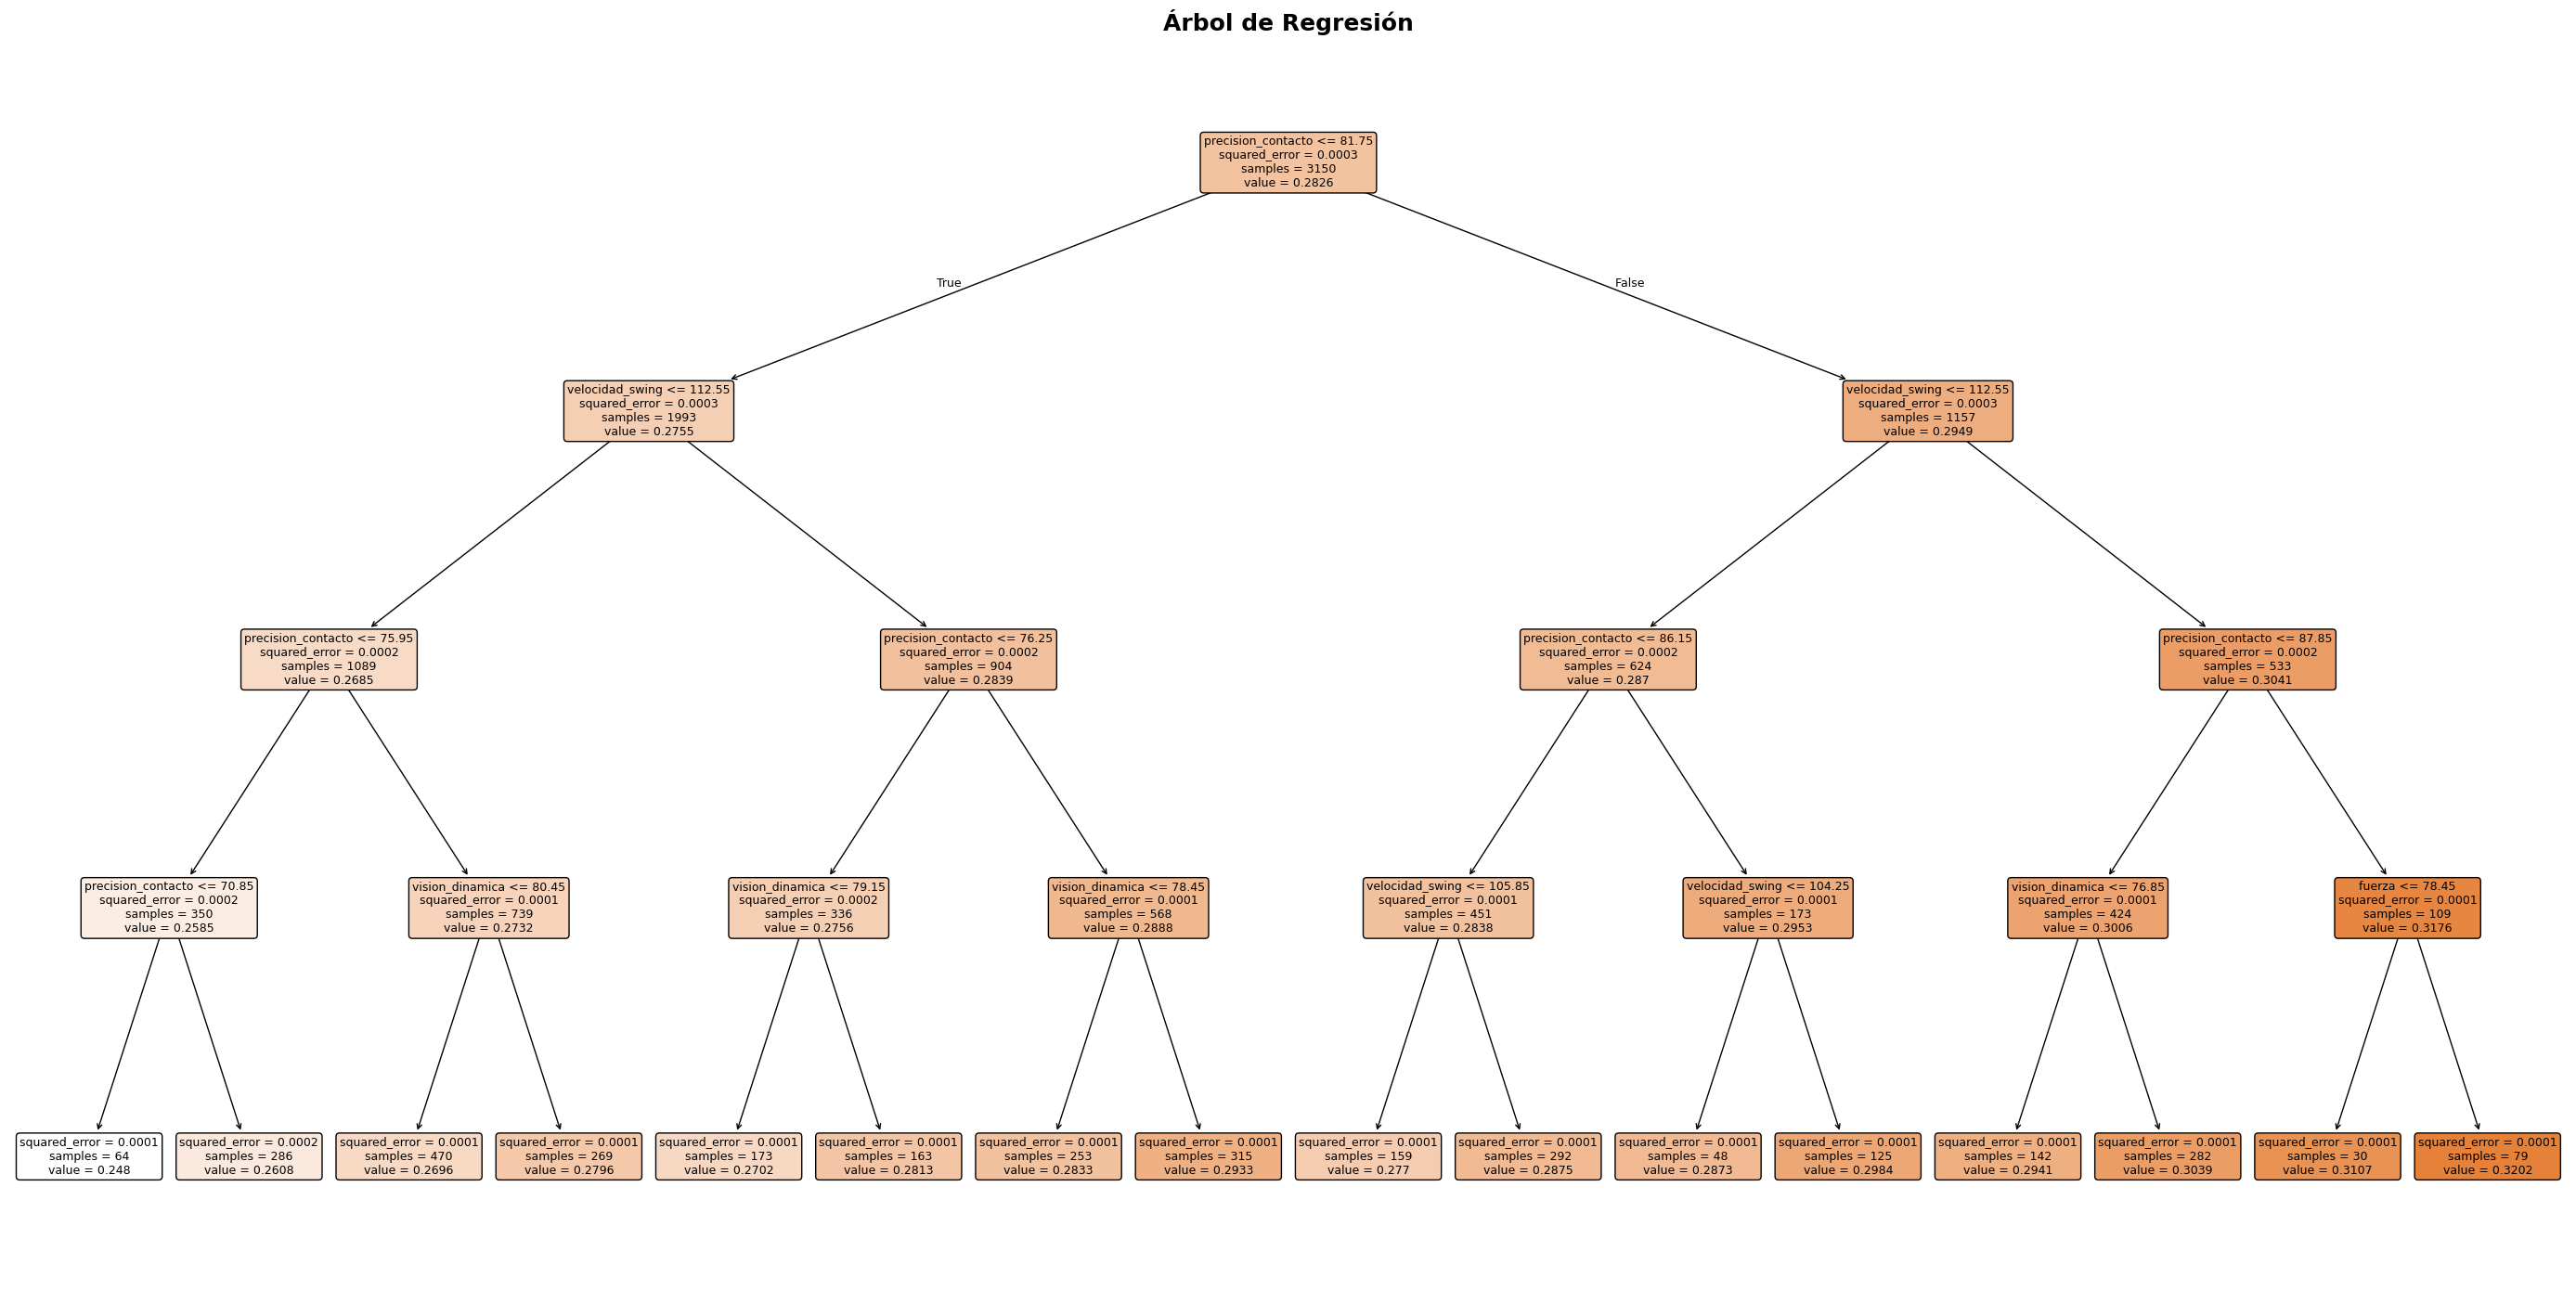

In [ ]:
f_visualizar_modelo_AR(modelo_AR, datos_entrenamiento, "pct_bateo")

### Variables importantes de AR

Se observa que las variables significativas para el modelo de árboles de regresión son *precision_contacto*, *velocidad_swing* y *vision_dinamica* como atributos técnicos del jugador para imparctar en las predicciones del porcentaje de bateo de manera importante .



In [ ]:
f_variables_importantes(modelo_AR, datos_entrenamiento, "pct_bateo")

,Variable,Importancia,Porcentaje
0,precision_contacto,0.6055,60.55
1,velocidad_swing,0.3177,31.77
2,vision_dinamica,0.0740,7.40
3,fuerza,0.0029,0.29
4,experiencia_mlb,0.0000,0.00
5,edad,0.0000,0.00
6,estatura_cm,0.0000,0.00
7,peso_kg,0.0000,0.00
8,agilidad,0.0000,0.00
9,tiempo_reaccion,0.0000,0.00


## Modelo random forest (RF)

Se cosntruye el modelo bosques aletorios o *random forest* con la función *f_crear_RF()* que recibe los argimentos de los datos de entrenamiento, la variabe dependiente *pct_bateo* y el número de árboles en el parámetro *n_estimators*.

In [ ]:
modelo_RF = f_crear_RF(datos_entrenamiento, "pct_bateo", n_estimators=500)
modelo_RF

MODELO BOSQUE ALEATORIO DE REGRESIÓN
Variable dependiente : pct_bateo
Observaciones        : 3150
Variables            : 10
Número de árboles    : 500


RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=2026)

### Variables principales

Con la función *f_variables_importantes()* se identifican las variable importantes en el modelo *random forest* . Este modelo de *random forest*, al igual que el modelo de árboles de regesión, también indica que las variable imkportante son para predecir el porcentaje de abteo son de tipo técnico o habilidades en relación a la biomecánica de bateo de un judgador de beisbol; estas variables de importancia son *precision_contacto*, *velocidad_swing* y *vision_dinamica*.  



In [ ]:
f_variables_importantes(modelo_RF, datos_entrenamiento, "pct_bateo")

,Variable,Importancia,Porcentaje
0,precision_contacto,0.4315,43.15
1,velocidad_swing,0.2858,28.58
2,vision_dinamica,0.0985,9.85
3,agilidad,0.0606,6.06
4,fuerza,0.0553,5.53
5,tiempo_reaccion,0.0249,2.49
6,estatura_cm,0.0143,1.43
7,peso_kg,0.0136,1.36
8,edad,0.0080,0.80
9,experiencia_mlb,0.0076,0.76


## Modelo regresión lineal múltiple

Se construye el modelo de regresión lineal múltiple con la función descrita anterioremente para otros casos de estudio; *f_construir_modelo_RLM_statsmodels()*.

In [ ]:
modelo_RLM = f_construir_modelo_RLM_statsmodels(datos_entrenamiento, "pct_bateo")
modelo_RLM

                            OLS Regression Results                            
Dep. Variable:              pct_bateo   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     2675.
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        21:19:04   Log-Likelihood:                 11655.
No. Observations:                3150   AIC:                        -2.329e+04
Df Residuals:                    3139   BIC:                        -2.322e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.2429      0

## Validación de postulados


Se manda llamar la función ** que valida sobre todo el modelo de regresión ñineal multipl eya que los modelso de arboles de regresión y bosaques aleatorios siendo modelos no paramétricos no se validan con estos postulados de regresión.



In [ ]:
resultado_postulados = f_validar_postulados_modelos( modelos=[modelo_RLM,
        modelo_AR,   modelo_RF ],
    datos_list = [datos_validacion,datos_validacion,datos_validacion],
    variable_dependiente="pct_bateo",
    nombres = ["RLM", "Arboles de regresión", "Random Forest"] )


VALIDACIÓN DE POSTULADOS
                 Modelo           Tipo  VIF_Max Linealidad Homocedasticidad  \
0                   RLM         lineal   12.406     Cumple           Cumple   
1  Arboles de regresión          arbol      NaN  No aplica        No aplica   
2         Random Forest  random_forest      NaN  No aplica        No aplica   

  Normalidad Independencia  
0     Cumple        Cumple  
1  No aplica     No aplica  
2  No aplica     No aplica  


## Evaluación de modelos

Ahora, ejecutando la función *f_evaluacion_modelos()* se generan los estaídticos aue permiten evalura la calidad predictiva de los modelos construidos en este caso de estudio.


In [ ]:
f_evaluacion_modelos(modelos=[modelo_RLM, modelo_AR, modelo_RF],
    datos_validacion=datos_validacion,
    variable_dependiente="pct_bateo",
    nombres=["RLM", "Árbol de Regresión", "Random Forest"] )


EVALUACIÓN DE MODELOS
               Modelo           Tipo  Parametros  R_square  R_square_ajustado  \
0                 RLM         lineal          10    0.8955             0.8947   
1       Random Forest  random_forest         500    0.8408                NaN   
2  Árbol de Regresión          arbol          16    0.6005                NaN   

      MSE    RMSE     MAE  
0  0.0000  0.0060  0.0048  
1  0.0001  0.0074  0.0059  
2  0.0001  0.0118  0.0093  


,Modelo,Tipo,Parametros,R_square,R_square_ajustado,MSE,RMSE,MAE
0,RLM,lineal,10,0.8955,0.8947,0.0000,0.0060,0.0048
1,Random Forest,random_forest,500,0.8408,NaN,0.0001,0.0074,0.0059
2,Árbol de Regresión,arbol,16,0.6005,NaN,0.0001,0.0118,0.0093


# Interpretación del caso


Se cumple con el objetivo del caso de estudio de construir , evaluar y comparar los modelos de regresión.  

Se construyeron tres modelos de predictivos, árboles de regresión, bosques aleatorios y regresión lineal múltiple con datos de porcentaje de bateo de jugadores de beisbol.

Todos los modelos utilizaron datos originales sin estandarizar ni escalar valores; del todal de los datos, el *70%* fue para datos de entrenamiento y el *30%* para datos de validación.

Todos los modelos tuvieron calidad predictiva por encimal del *50%* de acuerdo con el estadístico de evaluaicón *r square* y satisfacen la expectativa inicialmente establecida de ser mayor del 50% para este caso de estudio.

De los tres modelos construidos, el modelo que mejor calidad predictiva ofrece para estos datos es el de regresión lineal múltiple.




